In [1]:
!pip install -q keras-nlp matplotlib

In [2]:
import pandas as pd
import keras_nlp
import tensorflow as tf
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from tensorflow import keras

In [3]:
# Load the fine-tuned model
gpt2_lm = keras.models.load_model("/kaggle/input/gpt2_dialog_v1/keras/default/2/fine_tuned_gpt2_dialog_v2.keras", compile=False)

# (Re)compile with same or new optimizer
gpt2_lm.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-5))

/usr/local/lib/python3.10/dist-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 394 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# Load dataset
df = pd.read_feather("/kaggle/input/diagnoise-me/diagnose_en_dataset.feather").iloc[30000:45000]
print(df[["Patient", "Doctor"]].head())

# Combine question and answer into dialogue format
df["text"] = df.apply(lambda row: f"Patient: {row['Patient']}\nDoctor: {row['Doctor']}", axis=1)

                                                 Patient  \
30000  Hi doctor, I was about to get a complete blood...   
30001  Hello doctor, I am seriously facing acne pimpl...   
30002  Hi doctor, I am a 22 year old female. I have a...   
30003  Hi doctor, My son is 2.5 years old. For a week...   
30004  Hello doctor, I developed a rash on my foot ye...   

                                                  Doctor  
30000  Hi. For further information consult a family p...  
30001  Hello. Acne is a universal issue in the age gr...  
30002  Hi. One's skin color has 2 components. First o...  
30003  Hi. I can understand your concerns. Complain o...  
30004  Hi. Revert back with the answers to the above ...  


In [5]:
# Split the dataset into training and validation sets
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
print(f"Train size: {train_df.shape}")
print(f"Validation size: {val_df.shape}")

batch_size = 2
train_ds = tf.data.Dataset.from_tensor_slices(train_df["text"].values)
train_ds = train_ds.shuffle(buffer_size=len(train_df)).batch(batch_size)

val_ds = tf.data.Dataset.from_tensor_slices(val_df["text"].values)
val_ds = val_ds.shuffle(buffer_size=len(val_df)).batch(batch_size)

Train size: (12000, 5)
Validation size: (3000, 5)


In [6]:
history = gpt2_lm.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4228s 693ms/step - loss: 0.6494 - sparse_categorical_accuracy: 0.4234 - val_loss: 0.5760 - val_sparse_categorical_accuracy: 0.4795
Epoch 2/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4154s 692ms/step - loss: 0.5527 - sparse_categorical_accuracy: 0.4839 - val_loss: 0.5568 - val_sparse_categorical_accuracy: 0.4937
Epoch 3/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4155s 692ms/step - loss: 0.5102 - sparse_categorical_accuracy: 0.5035 - val_loss: 0.5498 - val_sparse_categorical_accuracy: 0.5006
Epoch 4/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4164s 694ms/step - loss: 0.4871 - sparse_categorical_accuracy: 0.5223 - val_loss: 0.5486 - val_sparse_categorical_accuracy: 0.5040
Epoch 5/5
6000/6000 ━━━━━━━━━━━━━━━━━━━━ 4153s 692ms/step - loss: 0.4557 - sparse_categorical_accuracy: 0.5405 - val_loss: 0.5480 - val_sparse_categorical_accuracy: 0.5057


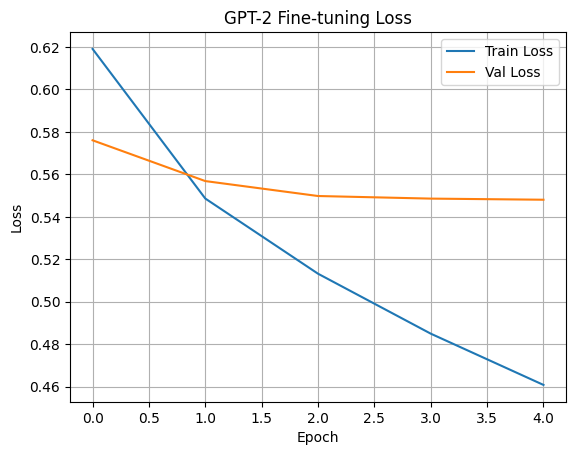

In [7]:
# Save fine-tuned model
gpt2_lm.save("/kaggle/working/fine_tuned_gpt2_dialog_v2.keras")

# Plot training loss
plt.plot(history.history["loss"], label="Train Loss")
if "val_loss" in history.history:
    plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("GPT-2 Fine-tuning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("training_loss_plot.png")
plt.show()

In [8]:
# Create a list to hold test results
results = []

# Generate and collect answers for 10 random questions
sample_df = df.sample(10, random_state=42)[["Patient", "Doctor"]]

for i, row in sample_df.iterrows():
    question = row["Patient"]
    true_answer = row["Doctor"]
    prompt = f"Patient: {question}\nDoctor:"
    
    # Generate model response
    generated = gpt2_lm.generate(prompt, max_length=100)
    
    # Save to results
    results.append({
        "question": question,
        "true_answer": true_answer,
        "generated_answer": generated
    })

# Save results to a DataFrame and then to CSV
results_df = pd.DataFrame(results)
results_df.to_csv("/kaggle/working/test_results.csv", index=False)
print("✅ Saved test results to /kaggle/working/test_results.csv")

✅ Saved test results to /kaggle/working/test_results.csv
